# Model Training

### Setup MLFlow

In [ ]:
# # SETUP BLOCK (Run once per project lifetime)
# import mlflow
# import os

# # 1. Define Absolute Paths
# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# db_uri = f"sqlite:///{os.path.join(project_root, 'mlflow.db')}"
# artifact_uri = "file:///" + os.path.join(project_root, "mlruns").replace("\\", "/")

# # 2. Connect
# mlflow.set_tracking_uri(db_uri)

# # 3. Create (Safe Check)
# if not mlflow.get_experiment_by_name("WaterQuality"):
#     mlflow.create_experiment("WaterQuality", artifact_location=artifact_uri)

2026/03/09 15:40:43 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/09 15:40:43 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [20]:
import mlflow
import os

# Set tracking URI (relative to notebook location)
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

# Set experiment name
mlflow.set_experiment("WaterQuality")

<Experiment: artifact_location='file:///d:/projects/water-quality-prediction/notebooks/mlruns/1', creation_time=1773038149702, experiment_id='1', last_update_time=1773038149702, lifecycle_stage='active', name='WaterQuality', tags={}>

### Import Libraries

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap
import time

from sklearn.inspection import permutation_importance

# Regression Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings("ignore")

### Load Preprocessed Data

In [3]:
TRAIN_DATA_PATH = '../data/processed/train_fe.parquet'
TEST_DATA_PATH = '../data/processed/test_fe.parquet'

TARGET_COLS = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

train_df = pd.read_parquet(TRAIN_DATA_PATH)
test_df = pd.read_parquet(TEST_DATA_PATH)

X_train = train_df.drop(columns=TARGET_COLS)
y_train = train_df[TARGET_COLS]

X_test = test_df.drop(columns=TARGET_COLS)
y_test = test_df[TARGET_COLS]

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes:  X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(7455, 29), y=(7455, 3)
Test shapes:  X=(1864, 29), y=(1864, 3)


### Define Model Hyperparameters

In [ ]:
data_params = {
    "pipeline_architecture": "ColumnTransformer",
    "imputation_strategy": "Median + Indicator (Num) / Constant (Cat) via Train Set Only",
    "fe_encoding": "OneHotEncoder for Month Categorical",      
    "data_split_ratio": "80/20 (Random Split)",
    "leakage_prevention": "Strict fit on X_train, transform on X_test",
    "storage_format": "Parquet instead of CSV", 
    "target_handling": "TransformedTargetRegressor (log1p) for DRP" 
}

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

target = TARGET_COLS

### Model Training & Evaluation

In [22]:
results = []

for target in TARGET_COLS:
    for model_name, base_model in models.items():
        run_name = f"{model_name}_{target.replace(' ', '')}"
        
        # Handle the massive DRP skew with a log transformation
        if target == "Dissolved Reactive Phosphorus":
            model = TransformedTargetRegressor(
                regressor=base_model,
                func=np.log1p,
                inverse_func=np.expm1,
            )
        else:
            model = base_model

        with mlflow.start_run(run_name=run_name):
            print(f"\n--- Training {run_name} ---")
            
            # --- Log Hyperparameters & Data Preprocessing ---
            mlflow.log_params(data_params)
            mlflow.log_param("target", target)
            mlflow.log_param("model", model_name)
            mlflow.log_param("input_rows", X_train.shape[0])
            mlflow.log_param("input_cols", X_train.shape[1])
            mlflow.log_params({
                k: v for k, v in base_model.get_params().items()
                if isinstance(v, (int, float, str, bool, type(None)))
            })

            # Log code snapshots (if you have them saved locally)
            if os.path.exists("01_eda_and_discovery.ipynb"):
                mlflow.log_artifact("01_eda_and_discovery.ipynb", artifact_path="code_snapshot")

            # --- Train ---
            train_start = time.time()
            model.fit(X_train, y_train[target])
            train_time = time.time() - train_start
            # For XGBoost, we want to pass the eval_set to generate the loss graph
            # if model_name == "XGBoost":
            #     # If wrapped in TransformedTargetRegressor, we must transform the eval set manually for XGBoost
            #     y_train_eval = np.log1p(y_train[target]) if target == "Dissolved Reactive Phosphorus" else y_train[target]
            #     y_test_eval = np.log1p(y_test[target]) if target == "Dissolved Reactive Phosphorus" else y_test[target]
                
            #     fit_params = {
            #         "regressor__eval_set": [(X_train, y_train_eval), (X_test, y_test_eval)],
            #         "regressor__verbose": False
            #     } if target == "Dissolved Reactive Phosphorus" else {
            #         "eval_set": [(X_train, y_train_eval), (X_test, y_test_eval)],
            #         "verbose": False
            #     }
            #     model.fit(X_train, y_train[target], **fit_params)
            # else:
            #     model.fit(X_train, y_train[target])
            

            # --- Predict & Metrics ---
            pred_start = time.time()
            y_pred = model.predict(X_test)
            pred_time = time.time() - pred_start
            
            metrics = {
                "rmse": np.sqrt(mean_squared_error(y_test[target], y_pred)),
                "mae": mean_absolute_error(y_test[target], y_pred),
                "r2": r2_score(y_test[target], y_pred),
                "train_time_sec": train_time,
                "pred_time_sec": pred_time
            }
            mlflow.log_metrics(metrics)
            
            # --- Loss Graph (Overfitting Figure) ---
            # if model_name == "XGBoost":
            #     # Extract the base XGBoost model to get the evals_result
            #     xgb_base = model.regressor_ if isinstance(model, TransformedTargetRegressor) else model
            #     results_dict = xgb_base.evals_result()
                
            #     fig, ax = plt.subplots(figsize=(8, 5))
            #     epochs = len(results_dict['validation_0']['rmse'])
            #     x_axis = range(0, epochs)
            #     ax.plot(x_axis, results_dict['validation_0']['rmse'], label='Train RMSE')
            #     ax.plot(x_axis, results_dict['validation_1']['rmse'], label='Test RMSE')
            #     ax.legend()
            #     ax.set_ylabel('RMSE')
            #     ax.set_xlabel('Boosting Rounds')
            #     ax.set_title(f'XGBoost Learning Curve - {target}')
            #     mlflow.log_figure(fig, 'learning_curve.png')
            #     plt.close(fig)

            # --- Actual vs Predicted Plot (Replaces Confusion Matrix) ---
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.scatter(y_test[target], y_pred, alpha=0.4, color='teal')
            # Draw the perfect prediction line
            min_val = min(y_test[target].min(), y_pred.min())
            max_val = max(y_test[target].max(), y_pred.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
            ax.set_xlabel('Actual Values')
            ax.set_ylabel('Predicted Values')
            ax.set_title(f'Actual vs Predicted - {run_name}')
            mlflow.log_figure(fig, 'actual_vs_predicted.png')
            plt.close(fig)

            # --- Residual Plot ---
            residuals = y_test[target] - y_pred
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.scatter(y_pred, residuals, alpha=0.4, color='purple')
            ax.axhline(0, color='red', linestyle='--')
            ax.set_xlabel('Predicted Values')
            ax.set_ylabel('Residuals (Error)')
            ax.set_title('Residual Plot (Checking for Variance)')
            mlflow.log_figure(fig, 'residuals.png')
            plt.close(fig)

            # --- Feature Importance: Permutation ---
            print('Computing Permutation Importance...')
            perm_importance = permutation_importance(
                model, X_test, y_test[target], n_repeats=5, random_state=42, n_jobs=-1
            )
            
            perm_df = pd.DataFrame({
                'feature': X_test.columns,
                'importance_mean': perm_importance.importances_mean,
            }).sort_values('importance_mean', ascending=True).tail(15) # Top 15
            
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.barh(perm_df['feature'], perm_df['importance_mean'], color='steelblue')    
            ax.set_xlabel('Mean Decrease in R2')
            ax.set_title(f'Permutation Importance - {run_name}')
            mlflow.log_figure(fig, 'permutation_importance.png')
            plt.close(fig)

            # --- Feature Importance: SHAP (Tree Models Only) ---
            if model_name in ["RandomForest", "XGBoost"]:
                print('Computing SHAP values...')
                # We MUST extract the base model if it's wrapped in a Target Transformer
                base_estimator = model.regressor_ if isinstance(model, TransformedTargetRegressor) else model
                
                # Sample for speed
                X_test_sample = X_test.sample(min(300, len(X_test)), random_state=42)
                explainer = shap.TreeExplainer(base_estimator)
                shap_values = explainer.shap_values(X_test_sample)
                
                fig = plt.figure(figsize=(10, 8))
                shap.summary_plot(shap_values, X_test_sample, show=False)
                plt.title(f'SHAP Summary - {run_name}')
                mlflow.log_figure(fig, 'shap_summary.png')
                plt.close(fig)

            # --- Log Model & Save Results ---
            mlflow.sklearn.log_model(model, name="model")
            results.append({
                "target": target,
                "model": model_name,
                "rmse": metrics["rmse"],
                "mae": metrics["mae"],
                "r2": metrics["r2"],
                "train_time_sec": train_time,
                "pred_time_sec": pred_time
            })

print("\n=== All 9 runs complete! Open MLflow UI to view visual artifacts. ===")


--- Training Ridge_TotalAlkalinity ---
Computing Permutation Importance...

--- Training RandomForest_TotalAlkalinity ---
Computing Permutation Importance...
Computing SHAP values...

--- Training XGBoost_TotalAlkalinity ---
Computing Permutation Importance...
Computing SHAP values...

--- Training Ridge_ElectricalConductance ---
Computing Permutation Importance...

--- Training RandomForest_ElectricalConductance ---
Computing Permutation Importance...
Computing SHAP values...

--- Training XGBoost_ElectricalConductance ---
Computing Permutation Importance...
Computing SHAP values...

--- Training Ridge_DissolvedReactivePhosphorus ---
Computing Permutation Importance...

--- Training RandomForest_DissolvedReactivePhosphorus ---
Computing Permutation Importance...
Computing SHAP values...

--- Training XGBoost_DissolvedReactivePhosphorus ---
Computing Permutation Importance...
Computing SHAP values...

=== All 9 runs complete! Open MLflow UI to view visual artifacts. ===


### Model Comparison

In [23]:
results_df = pd.DataFrame(results)

# Pivot for a clean comparison view
for metric in ["rmse", "mae", "r2"]:
    print(f"\n{'='*50}")
    print(f"  {metric.upper()} by Target × Model")
    print(f"{'='*50}")
    pivot = results_df.pivot(index="target", columns="model", values=metric)
    pivot = pivot[["Ridge", "RandomForest", "XGBoost"]]  # fix column order
    
    # Highlight min for rmse/mae, max for r2
    if metric in ["rmse", "mae"]:
        display(pivot.style.highlight_min(axis=1, color="lightgreen").format("{:.4f}"))
    else:
        display(pivot.style.highlight_max(axis=1, color="lightgreen").format("{:.4f}"))


  RMSE by Target × Model


model,Ridge,RandomForest,XGBoost
target,,,
Dissolved Reactive Phosphorus,51.5058,30.8149,34.8575
Electrical Conductance,304.7695,141.8661,151.5291
Total Alkalinity,66.0475,32.6964,35.5515



  MAE by Target × Model


model,Ridge,RandomForest,XGBoost
target,,,
Dissolved Reactive Phosphorus,31.1916,16.3796,19.6962
Electrical Conductance,241.6776,82.4072,99.9619
Total Alkalinity,52.4222,21.0046,24.5178



  R2 by Target × Model


model,Ridge,RandomForest,XGBoost
target,,,
Dissolved Reactive Phosphorus,0.0116,0.6462,0.5473
Electrical Conductance,0.2219,0.8314,0.8077
Total Alkalinity,0.2422,0.8143,0.7804


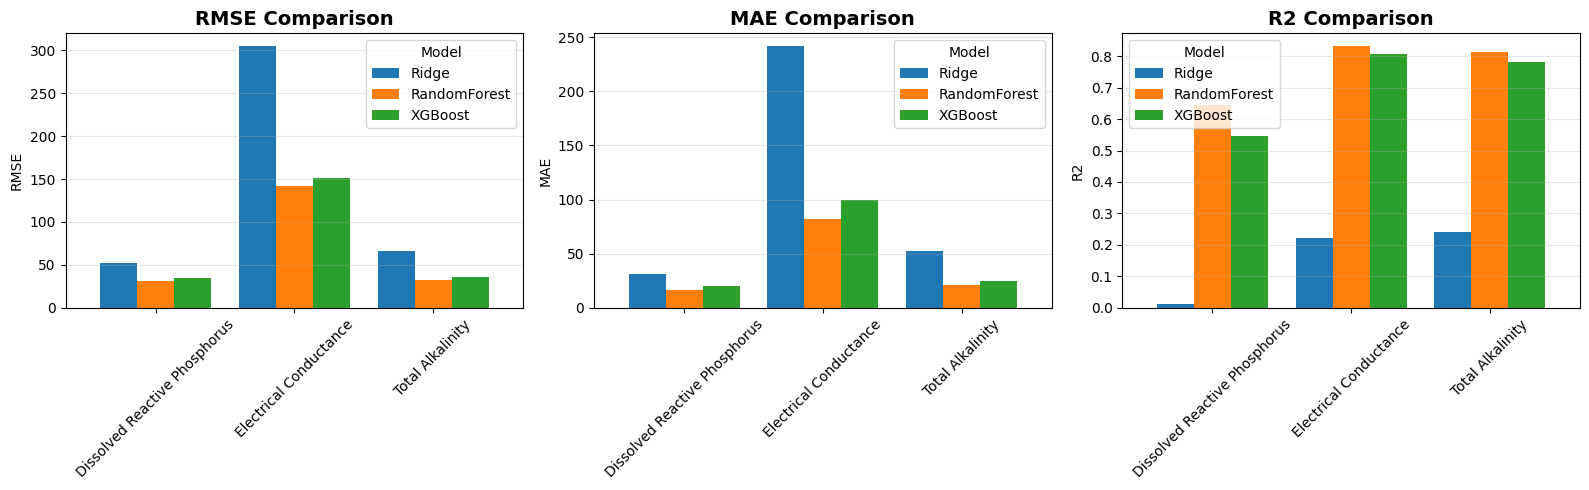


✅ Saved to ../reports/model_comparison.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["rmse", "mae", "r2"]):
    pivot = results_df.pivot(index="target", columns="model", values=metric)
    pivot = pivot[["Ridge", "RandomForest", "XGBoost"]]
    pivot.plot(kind="bar", ax=ax, rot=45, width=0.8)
    ax.set_title(f"{metric.upper()} Comparison", fontsize=14, fontweight='bold')
    ax.set_ylabel(metric.upper())
    ax.set_xlabel("")
    ax.legend(title="Model", loc='best')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Saved to ../reports/model_comparison.png")